# DeGroot Latent Belief Baseline (Alpha-Only)

This notebook separates latent belief from message expression:
- latent state $z_i(t)$ defaults to the profile proxy `topology_profile_for_agent.ss`
- optionally, $z_i(t)$ can be loaded from `latent_belief_global.jsonl` (global latent-belief pipeline output)
- observed message stance $x_i(t)$ is read from `messages_with_alignment.jsonl` (`published.stance_score`)
- expressive noise is $\eta_i(t)=x_i(t)-z_i(t)$

Dynamics are baseline DeGroot on latent belief state:
$$z_i(t+1)=\alpha z_i(t)+(1-\alpha)\,\text{social}_i(t).$$

Observed stance $x_i(t)$ is used only for expression diagnostics.

In [1]:
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
ROOT = Path.cwd().parent.parent.parent
CLEAN = ROOT / 'modeling' / 'cleaned_data'
RUN_DIRS = sorted([p for p in CLEAN.glob('run_*') if p.is_dir()])
assert RUN_DIRS, f'No run_* folders in {CLEAN}'

# If available, prefer the exported global innate-belief file created by
# `latent_belief/degroot_gaussian_noise_study.ipynb`.
USE_GLOBAL_LATENT = True
GLOBAL_LATENT_FILENAME = 'latent_belief_global.jsonl'
# Default: use the debiased innate belief (no smoothing baked in here).
GLOBAL_LATENT_FIELD = 'z_innate_debiased'

PARAMS = {
    # Denser baseline sweep; still alpha-only.
    'alpha_grid': np.linspace(0.0, 1.0, 21).tolist(),
}


def load_json(path: Path):
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)


def load_jsonl(path: Path):
    rows = []
    if not path.exists():
        return rows
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def numeric_agent_key(agent_id: str):
    if isinstance(agent_id, str) and agent_id.startswith('agent_'):
        tail = agent_id.split('_')[-1]
        if tail.isdigit():
            return int(tail)
    return 10**9


def parse_agent_id(v):
    if isinstance(v, str) and v.startswith('agent_'):
        return v
    if isinstance(v, int):
        return f'agent_{v}'
    return None


def to_int_list(values):
    out = []
    if not isinstance(values, list):
        return out
    for x in values:
        try:
            out.append(int(x))
        except Exception:
            continue
    return out


def build_message_lookup(run_dir: Path):
    lookup = {}
    messages = load_jsonl(run_dir / 'messages_with_alignment.jsonl')
    for m in messages:
        idx = m.get('index', None)
        if idx is None:
            continue
        try:
            k = int(idx)
        except Exception:
            continue

        time_slice = m.get('time_slice', None)
        if time_slice is None and isinstance(m.get('time'), dict):
            time_slice = m['time'].get('time_slice', None)
        if time_slice is not None:
            try:
                time_slice = int(time_slice)
            except Exception:
                time_slice = None

        lookup[k] = {
            'sender': parse_agent_id(m.get('sender_id')),
            'message_text': m.get('message', '') or '',
            'obs_x': float((m.get('published') or {}).get('stance_score'))
            if (m.get('published') or {}).get('stance_score') is not None
            else np.nan,
            'time_slice': time_slice,
        }
    return lookup


def build_events_from_per_agent(run_dir: Path):
    events = []
    per_agent_dir = run_dir / 'per_agent'
    if not per_agent_dir.exists():
        return events
    for fp in sorted(per_agent_dir.glob('agent_*.jsonl')):
        target = fp.stem
        for row in load_jsonl(fp):
            topo = row.get('topology_profile_for_agent', {}) or {}
            ss = topo.get('ss', None)
            msg_index = row.get('message_index', None)
            if ss is None or msg_index is None:
                continue

            msg_slice = row.get('message_time_slice', None)
            if msg_slice is None and isinstance(row.get('time'), dict):
                msg_slice = row['time'].get('time_slice', None)
            try:
                msg_slice = int(msg_slice) if msg_slice is not None else None
            except Exception:
                msg_slice = None

            rec_indices = to_int_list(row.get('recommendation_indices'))
            if not rec_indices:
                rec_indices = to_int_list(row.get('used_indices'))

            sender = parse_agent_id(row.get('influenced_by'))
            obs_x_raw = (row.get('published') or {}).get('stance_score', None)
            obs_x = float(obs_x_raw) if obs_x_raw is not None else np.nan
            events.append(
                {
                    't': int(msg_index),
                    'time_slice': msg_slice,
                    'target': target,
                    'sender': sender,
                    'obs_z': float(ss),
                    'obs_x': obs_x,
                    'message_text': row.get('message', '') or '',
                    'rec_indices': rec_indices,
                }
            )
    events.sort(key=lambda e: (e['t'], numeric_agent_key(e['target'])))
    return events


def build_events_from_global_latent(
    run_dir: Path,
    message_lookup: dict,
    z_field: str = GLOBAL_LATENT_FIELD,
):
    """Load innate-belief observations exported by the global noise-debias pipeline."""

    fp = run_dir / GLOBAL_LATENT_FILENAME
    events = []
    if not fp.exists():
        return events

    for row in load_jsonl(fp):
        if isinstance(row, dict) and '_meta' in row:
            continue
        if not isinstance(row, dict):
            continue

        t = row.get('t', None)
        agent = row.get('agent', None)
        if t is None or agent is None:
            continue
        try:
            t = int(t)
        except Exception:
            continue

        z_val = row.get(z_field, None)
        obs_z = float(z_val) if z_val is not None else np.nan

        msg_meta = message_lookup.get(t, {})
        msg_slice = msg_meta.get('time_slice', None)
        if msg_slice is None:
            msg_slice = row.get('time_slice', None)
        try:
            msg_slice = int(msg_slice) if msg_slice is not None else None
        except Exception:
            msg_slice = None

        obs_x = row.get('obs_x', None)
        if obs_x is None or not np.isfinite(float(obs_x)) if obs_x is not None else True:
            obs_x = msg_meta.get('obs_x', np.nan)
        try:
            obs_x = float(obs_x)
        except Exception:
            obs_x = np.nan

        events.append(
            {
                't': t,
                'time_slice': msg_slice,
                'target': str(agent),
                'sender': None,
                'obs_z': obs_z,
                'obs_x': obs_x,
                'rec_indices': [],
            }
        )

    events.sort(key=lambda e: (e['t'], numeric_agent_key(e['target'])))
    return events


def get_graph_adjacency(graph):
    if isinstance(graph, dict) and 'edges' in graph:
        adj = defaultdict(list)
        for src, dst in graph.get('edges', []):
            s = parse_agent_id(src)
            d = parse_agent_id(dst)
            if s and d:
                adj[s].append(d)
        return dict(adj)
    if isinstance(graph, dict):
        return {k: list(v) for k, v in graph.items() if isinstance(v, list)}
    return {}


def obs_count(run_dir: Path):
    message_lookup = build_message_lookup(run_dir)
    if USE_GLOBAL_LATENT and (run_dir / GLOBAL_LATENT_FILENAME).exists():
        ev = build_events_from_global_latent(run_dir, message_lookup)
        return len(ev)
    events = build_events_from_per_agent(run_dir)
    return len(events)


if USE_GLOBAL_LATENT:
    runs_with_global = [p for p in RUN_DIRS if (p / GLOBAL_LATENT_FILENAME).exists()]
    CANDIDATE_RUNS = runs_with_global if runs_with_global else RUN_DIRS
else:
    CANDIDATE_RUNS = RUN_DIRS

RUN_DIR = max(CANDIDATE_RUNS, key=obs_count)
print('Using run:', RUN_DIR.name, 'event_obs=', obs_count(RUN_DIR))
print('Using global latent file:', bool(USE_GLOBAL_LATENT and (RUN_DIR / GLOBAL_LATENT_FILENAME).exists()))


def load_run_data(run_dir: Path):
    graph_raw = load_json(run_dir / 'connection_graph.json')
    graph = get_graph_adjacency(graph_raw)

    message_lookup = build_message_lookup(run_dir)
    if USE_GLOBAL_LATENT and (run_dir / GLOBAL_LATENT_FILENAME).exists():
        events = build_events_from_global_latent(run_dir, message_lookup)
    else:
        events = build_events_from_per_agent(run_dir)

    agent_ids = set(graph.keys())
    for src, dsts in graph.items():
        agent_ids.add(src)
        agent_ids.update(dsts)

    for ev in events:
        agent_ids.add(ev['target'])
        if ev.get('sender') is not None:
            agent_ids.add(ev['sender'])

    for m in message_lookup.values():
        if m['sender'] is not None:
            agent_ids.add(m['sender'])

    agent_ids = sorted(agent_ids, key=numeric_agent_key)

    max_time_slice = 0
    for m in message_lookup.values():
        ts = m.get('time_slice', None)
        if ts is not None and ts > max_time_slice:
            max_time_slice = int(ts)
    for ev in events:
        ts = ev.get('time_slice', None)
        if ts is not None and ts > max_time_slice:
            max_time_slice = int(ts)

    self_obs_by_agent_slice = defaultdict(dict)
    for ev in events:
        ts = ev.get('time_slice', None)
        if ts is None:
            continue
        agent = ev['target']
        cur = self_obs_by_agent_slice[agent].get(int(ts))
        if cur is None or int(ev['t']) < int(cur['t']):
            self_obs_by_agent_slice[agent][int(ts)] = {
                't': int(ev['t']),
                'obs_z': float(ev['obs_z']) if np.isfinite(float(ev['obs_z'])) else np.nan,
                'obs_x': float(ev['obs_x']) if np.isfinite(float(ev['obs_x'])) else np.nan,
            }

    obs_seq_by_agent = defaultdict(list)
    for ev in events:
        z = ev.get('obs_z', np.nan)
        if z is not None and np.isfinite(float(z)):
            obs_seq_by_agent[ev['target']].append(float(z))

    return {
        'graph': graph,
        'events': events,
        'obs_seq_by_agent': obs_seq_by_agent,
        'agent_ids': agent_ids,
        'message_lookup': message_lookup,
        'self_obs_by_agent_slice': dict(self_obs_by_agent_slice),
        'max_time_slice': int(max_time_slice),
    }


def build_predecessors(graph, agent_ids):
    preds = {a: [] for a in agent_ids}
    for src, dsts in graph.items():
        for dst in dsts:
            if dst in preds:
                preds[dst].append(src)
    return preds


def initial_latent(obs_seq_by_agent, agent_ids, self_obs_by_agent_slice=None):
    z0 = {a: 0.0 for a in agent_ids}
    self_obs_by_agent_slice = self_obs_by_agent_slice or {}
    for a in agent_ids:
        s0 = (self_obs_by_agent_slice.get(a) or {}).get(0)
        if s0 is not None and np.isfinite(float(s0.get('obs_z', np.nan))):
            z0[a] = float(s0['obs_z'])
            continue
        seq = [v for v in obs_seq_by_agent.get(a, []) if np.isfinite(float(v))]
        if seq:
            z0[a] = float(seq[0])
    return z0


def evaluate(records, pred_key='pred_x', obs_key='obs_x'):
    if not records:
        return {'mae': np.nan, 'rmse': np.nan}
    d = np.array([r[pred_key] - r[obs_key] for r in records], dtype=float)
    d = d[np.isfinite(d)]
    if d.size == 0:
        return {'mae': np.nan, 'rmse': np.nan}
    return {'mae': float(np.mean(np.abs(d))), 'rmse': float(np.sqrt(np.mean(d * d))) }

Using run: run_20260307-175802 event_obs= 742
Using global latent file: True


In [8]:
def build_W_static(preds, agent_ids):
    n = len(agent_ids)
    idx = {a: i for i, a in enumerate(agent_ids)}
    W = np.zeros((n, n), dtype=float)
    for dst in agent_ids:
        j = idx[dst]
        p = preds.get(dst, [])
        if p:
            w = 1.0 / len(p)
            for src in p:
                if src in idx:
                    W[j, idx[src]] = w
        else:
            W[j, j] = 1.0
    return W, idx


def run_timeslice_degroot_latent(data, alpha=0.6):
    agent_ids = data['agent_ids']
    preds = build_predecessors(data['graph'], agent_ids)
    W, idx = build_W_static(preds, agent_ids)

    z0_dict = initial_latent(
        data['obs_seq_by_agent'],
        agent_ids,
        self_obs_by_agent_slice=data['self_obs_by_agent_slice'],
    )

    z = np.array([z0_dict[a] for a in agent_ids], dtype=float)
    alpha = float(alpha)

    effective_obs_z = {a: float(z0_dict[a]) for a in agent_ids}
    effective_obs_x = {a: np.nan for a in agent_ids}
    for a in agent_ids:
        s0 = (data['self_obs_by_agent_slice'].get(a) or {}).get(0)
        if s0 is not None:
            x0 = s0.get('obs_x', np.nan)
            if np.isfinite(float(x0)):
                effective_obs_x[a] = float(x0)

    records = []
    for time_slice in range(0, int(data['max_time_slice']) + 1):
        if time_slice > 0:
            social = W @ z
            z = np.clip(alpha * z + (1.0 - alpha) * social, -1.0, 1.0)

        for agent in agent_ids:
            self_obs = (data['self_obs_by_agent_slice'].get(agent) or {}).get(time_slice)
            has_self_post = self_obs is not None
            if has_self_post:
                obs_z = self_obs.get('obs_z', np.nan)
                obs_x = self_obs.get('obs_x', np.nan)
                if np.isfinite(float(obs_z)):
                    effective_obs_z[agent] = float(obs_z)
                if np.isfinite(float(obs_x)):
                    effective_obs_x[agent] = float(obs_x)

            pred_z = float(z[idx[agent]])
            obs_z = float(effective_obs_z[agent]) if np.isfinite(float(effective_obs_z[agent])) else np.nan
            obs_x = float(effective_obs_x[agent]) if np.isfinite(float(effective_obs_x[agent])) else np.nan

            eta = float(obs_x - obs_z) if np.isfinite(obs_x) and np.isfinite(obs_z) else np.nan
            belief_resid = float(obs_z - pred_z) if np.isfinite(obs_z) else np.nan
            expr_resid = float(obs_x - pred_z) if np.isfinite(obs_x) else np.nan

            records.append(
                {
                    'time_slice': int(time_slice),
                    'agent': agent,
                    'pred_z': pred_z,
                    'obs_z': obs_z,
                    'obs_x': obs_x,
                    'eta_hat': eta,
                    'belief_resid': belief_resid,
                    'expr_resid': expr_resid,
                    'has_self_post': bool(has_self_post),
                }
            )

    z_final = {agent: float(z[idx[agent]]) for agent in agent_ids}
    return {'z0': z0_dict, 'z_final': z_final, 'records': records, 'W': W, 'idx': idx}

## Flow of logic (simple)

1. Read latent proxy `z` from per-agent logs (`topology_profile_for_agent.ss`).
2. Read observed expression `x` from message logs (`published.stance_score`).
3. Compute expressive residual `η = x - z`.
4. Run DeGroot update on latent state only:
   $$z_i(t+1)=\alpha z_i(t)+(1-\alpha)\,\text{social}_i(t).$$
5. Evaluate prediction error against observed latent proxy `obs_z` (primary), and against `obs_x` only as diagnostic.

Data sources:
  z from: /home/sammli/llm-network/modeling/cleaned_data/run_20260307-175802/latent_belief_global.jsonl (field='z_innate_debiased')
  x from: /home/sammli/llm-network/modeling/cleaned_data/run_20260307-175802/latent_belief_global.jsonl (field='obs_x' fallback to message log)
agents= 30 max_time_slice= 37

Counts:
  direct observed rows: 559
  missing x rate: 0.0


,agent,time_slice,obs_z_direct,obs_x_direct,eta_direct
0,agent_1,0,0.320478,0.403713,0.083235
1,agent_1,1,0.484769,0.531323,0.046554
2,agent_1,2,0.490202,0.598371,0.108169
3,agent_1,3,0.599322,0.601883,0.002561
4,agent_1,5,0.572607,0.550747,-0.021860
5,agent_1,6,0.617293,0.599424,-0.017869
6,agent_1,7,0.683634,0.594146,-0.089488
7,agent_1,8,0.664043,0.578059,-0.085984
8,agent_1,9,0.592291,0.523245,-0.069045
9,agent_1,10,0.639913,0.570196,-0.069716



Equation proof on synchronized slices: z_pred = alpha*z_prev + (1-alpha)*(W@z_prev)
max abs diff (first slices) = 0.0


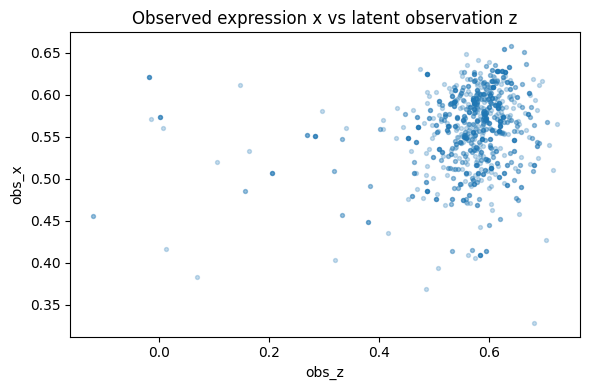

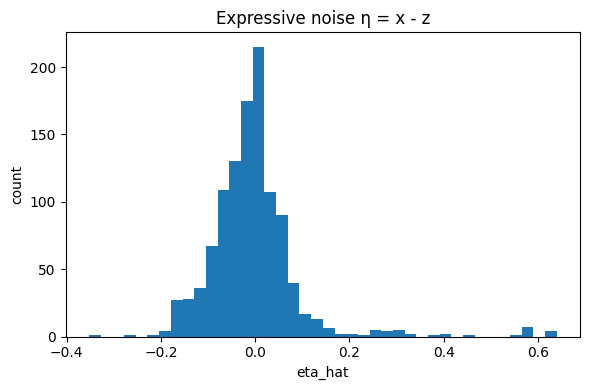

In [9]:
# Audit / proof cell (time-slice version)
print('Data sources:')
if USE_GLOBAL_LATENT and (RUN_DIR / GLOBAL_LATENT_FILENAME).exists():
    print('  z from:', RUN_DIR / GLOBAL_LATENT_FILENAME, f"(field='{GLOBAL_LATENT_FIELD}')")
    print('  x from:', RUN_DIR / GLOBAL_LATENT_FILENAME, "(field='obs_x' fallback to message log)")
else:
    print('  z from:', RUN_DIR / 'per_agent' / 'agent_*.jsonl')
    print('  x from:', RUN_DIR / 'messages_with_alignment.jsonl')

data_audit = load_run_data(RUN_DIR)
print('agents=', len(data_audit['agent_ids']), 'max_time_slice=', data_audit['max_time_slice'])

# Direct observed rows for sanity: one self-observation row per (agent, time_slice)
audit_rows = []
for agent, ts_map in data_audit['self_obs_by_agent_slice'].items():
    for ts, row in ts_map.items():
        audit_rows.append({
            'agent': agent,
            'time_slice': int(ts),
            'obs_z_direct': row.get('obs_z', np.nan),
            'obs_x_direct': row.get('obs_x', np.nan),
        })
audit_df = pd.DataFrame(audit_rows).sort_values(['agent', 'time_slice']).reset_index(drop=True)
audit_df['eta_direct'] = audit_df['obs_x_direct'] - audit_df['obs_z_direct']

print('\nCounts:')
print('  direct observed rows:', len(audit_df))
print('  missing x rate:', float(pd.isna(audit_df['obs_x_direct']).mean()) if len(audit_df) else np.nan)
display(audit_df.head(10))

# Numerical proof for synchronized DeGroot update
alpha_audit = float(PARAMS['alpha_grid'][0])
out_audit = run_timeslice_degroot_latent(data_audit, alpha=alpha_audit)
rec_df = pd.DataFrame(out_audit['records']).sort_values(['time_slice', 'agent']).reset_index(drop=True)

agent_order = data_audit['agent_ids']
W = out_audit['W']
z_prev = np.array([out_audit['z0'][a] for a in agent_order], dtype=float)
max_diff = 0.0
max_check_slice = min(int(data_audit['max_time_slice']), 15)

for ts in range(1, max_check_slice + 1):
    rhs = np.clip(alpha_audit * z_prev + (1.0 - alpha_audit) * (W @ z_prev), -1.0, 1.0)
    lhs = (
        rec_df[rec_df['time_slice'] == ts]
        .set_index('agent')
        .loc[agent_order, 'pred_z']
        .to_numpy(dtype=float)
    )
    max_diff = max(max_diff, float(np.nanmax(np.abs(lhs - rhs))))
    z_prev = rhs

print('\nEquation proof on synchronized slices: z_pred = alpha*z_prev + (1-alpha)*(W@z_prev)')
print('max abs diff (first slices) =', max_diff)

# Simple diagnostics plots
plt.figure(figsize=(6, 4))
plt.scatter(rec_df['obs_z'], rec_df['obs_x'], s=8, alpha=0.25)
plt.title('Observed expression x vs latent observation z')
plt.xlabel('obs_z')
plt.ylabel('obs_x')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(rec_df['eta_hat'].dropna(), bins=40)
plt.title('Expressive noise η = x - z')
plt.xlabel('eta_hat')
plt.ylabel('count')
plt.tight_layout()
plt.show()

In [10]:
data = load_run_data(RUN_DIR)
print('agents=', len(data['agent_ids']), 'max_time_slice=', data['max_time_slice'])
rows = []
for a in PARAMS['alpha_grid']:
    out = run_timeslice_degroot_latent(data, alpha=a)
    rec = out['records']
    m = evaluate(rec, pred_key='pred_z', obs_key='obs_z')
    rows.append({'alpha': a, 'n_eval': len(rec), **m})
res = pd.DataFrame(rows).sort_values('rmse').reset_index(drop=True)
res

agents= 30 max_time_slice= 37


,alpha,n_eval,mae,rmse
0,0.50,1140,0.274858,0.286446
1,0.55,1140,0.274578,0.286463
2,0.45,1140,0.275129,0.286481
3,0.40,1140,0.275389,0.286550
4,0.60,1140,0.274289,0.286554
5,0.35,1140,0.275638,0.286644
6,0.30,1140,0.275879,0.286755
7,0.65,1140,0.273994,0.286756
8,0.25,1140,0.276108,0.286879
9,0.20,1140,0.276329,0.287014


Best: {'alpha': 0.5, 'n_eval': 1140.0, 'mae': 0.27485818020576, 'rmse': 0.28644620716150987}
Baseline metrics vs latent z(t): {'mae': 0.27485818020576, 'rmse': 0.28644620716150987}
Diagnostic-only metrics vs observed x(t): {'mae': 0.27336799645887405, 'rmse': 0.2791642399603704}
eta mean/std: -0.003628609246116091 0.10090365426159587
belief residual mean/std: 0.26932822476990304 0.0975383870048465
expression residual mean/std: 0.2733674110670973 0.056594447069689746


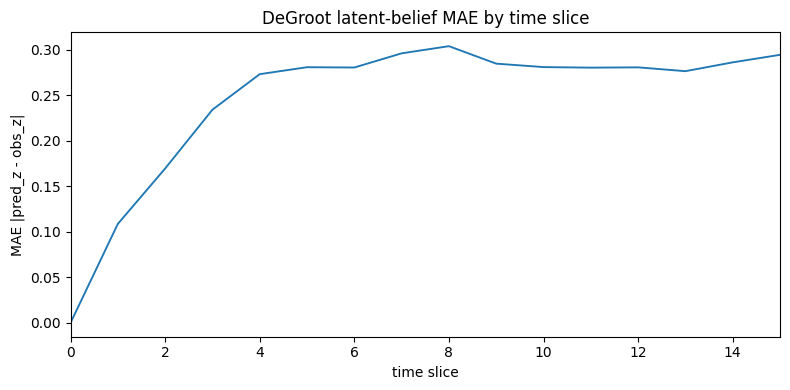

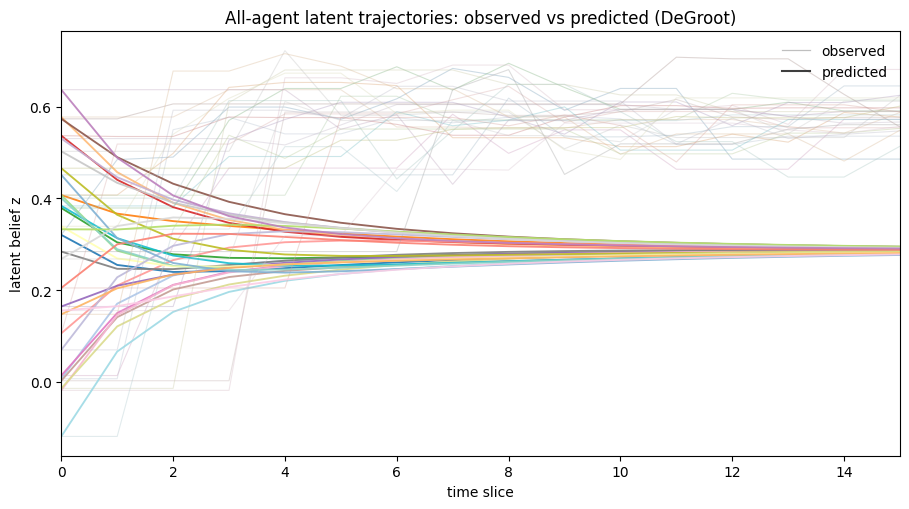

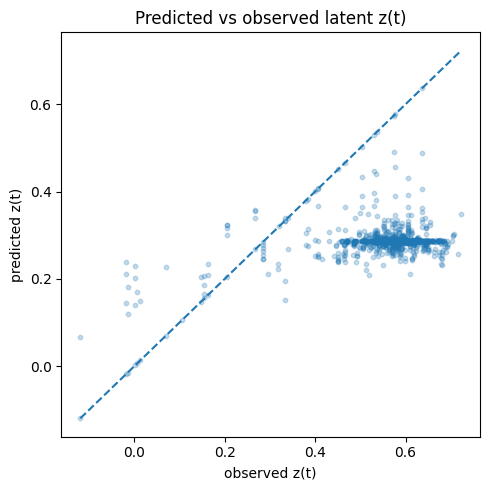

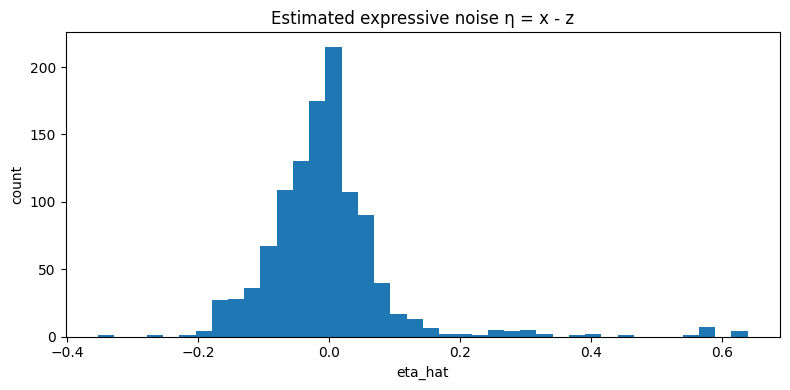

In [11]:
best = res.iloc[0].to_dict()
print('Best:', best)
out = run_timeslice_degroot_latent(data, alpha=float(best['alpha']))
df = pd.DataFrame(out['records']).sort_values(['agent', 'time_slice']).reset_index(drop=True)

valid_df = df.dropna(subset=['obs_x']).copy()
valid = valid_df.to_dict('records')
print('Baseline metrics vs latent z(t):', evaluate(df.to_dict('records'), pred_key='pred_z', obs_key='obs_z'))
print('Diagnostic-only metrics vs observed x(t):', evaluate(valid, pred_key='pred_z', obs_key='obs_x'))
print('eta mean/std:', float(np.nanmean(df['eta_hat'])), float(np.nanstd(df['eta_hat'])))
print('belief residual mean/std:', float(np.nanmean(df['belief_resid'])), float(np.nanstd(df['belief_resid'])))
print('expression residual mean/std:', float(np.nanmean(df['expr_resid'])), float(np.nanstd(df['expr_resid'])))

df['abs_err_z'] = (df['pred_z'] - df['obs_z']).abs()
err_t = df.groupby('time_slice', as_index=False)['abs_err_z'].mean()
plot_horizon = int(min(15, int(df['time_slice'].max()))) if not df.empty else 0
err_t = err_t[err_t['time_slice'] <= plot_horizon]
plt.figure(figsize=(8, 4))
plt.plot(err_t['time_slice'], err_t['abs_err_z'], color='tab:blue', linewidth=1.35)
plt.title('DeGroot latent-belief MAE by time slice')
plt.xlabel('time slice')
plt.ylabel('MAE |pred_z - obs_z|')
plt.xlim(0, max(1, plot_horizon))
plt.tight_layout()
plt.show()

from matplotlib.lines import Line2D

agent_order = sorted(df['agent'].unique(), key=numeric_agent_key)
palette = np.array(list(plt.cm.tab20.colors) + list(plt.cm.Set3.colors) + list(plt.cm.Dark2.colors))[:len(agent_order)]

plt.figure(figsize=(9.2, 5.2))
for i, agent in enumerate(agent_order):
    dfa = df[df['agent'] == agent].sort_values('time_slice')
    dfa = dfa[dfa['time_slice'] <= plot_horizon]
    base_rgb = np.asarray(palette[i][:3], dtype=float)
    obs_rgb = 0.55 * np.array([0.72, 0.72, 0.72]) + 0.45 * base_rgb
    plt.plot(
        dfa['time_slice'],
        dfa['obs_z'],
        color=(*obs_rgb, 0.35),
        linewidth=0.8,
        solid_capstyle='round',
    )
    plt.plot(
        dfa['time_slice'],
        dfa['pred_z'],
        color=(*base_rgb, 0.9),
        linewidth=1.35,
        solid_capstyle='round',
    )

legend_handles = [
    Line2D([0], [0], color=(0.45, 0.45, 0.45, 0.45), linewidth=0.9, label='observed'),
    Line2D([0], [0], color=(0.2, 0.2, 0.2, 0.95), linewidth=1.5, label='predicted'),
]
plt.title('All-agent latent trajectories: observed vs predicted (DeGroot)')
plt.xlabel('time slice')
plt.ylabel('latent belief z')
plt.xlim(0, max(1, plot_horizon))
plt.legend(handles=legend_handles, loc='upper right', frameon=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(df['obs_z'], df['pred_z'], s=10, alpha=0.25)
mn = float(np.nanmin([df['obs_z'].min(), df['pred_z'].min()]))
mx = float(np.nanmax([df['obs_z'].max(), df['pred_z'].max()]))
plt.plot([mn, mx], [mn, mx], linestyle='--')
plt.title('Predicted vs observed latent z(t)')
plt.xlabel('observed z(t)')
plt.ylabel('predicted z(t)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df['eta_hat'].dropna(), bins=40)
plt.title('Estimated expressive noise η = x - z')
plt.xlabel('eta_hat')
plt.ylabel('count')
plt.tight_layout()
plt.show()